#Лабораторна робота №8

##**Тема. Жадібні алгоритми. Наближене розв’язання екстремальних задач**  
##**Мета**: набути практичних навичок застосування деяких жадібних алгоритмів для розв’язання екстремальних задач.
##**Виконав:** Рафієв Б.

###**Завдання для самостійного розв’язання**

**Умова:** Задано зважений граф: [(1,2,5), (2,3,7), (2,4,3), (3,4,6)]. Необхідно розв’язати задачу комівояжера за допомогою алгоритму грубої сили (Brute Force), візуалізувати структуру графа та математично обґрунтувати асимптотичну складність обох методів.     
**1. Візуальна структура та аналіз графа**  
Заданий граф має 4 вершини ($1, 2, 3, 4$) та наступні зв'язки:
- Ребро $(1,2)$ з вагою $5$
- Ребро $(2,3)$ з вагою $7$
- Ребро $(2,4)$ з вагою $3$
- Ребро $(3,4)$ з вагою $6$.  
**2. Програмна реалізація та візуалізація на Python. Реалізація класичних алгоритмів на графах**  

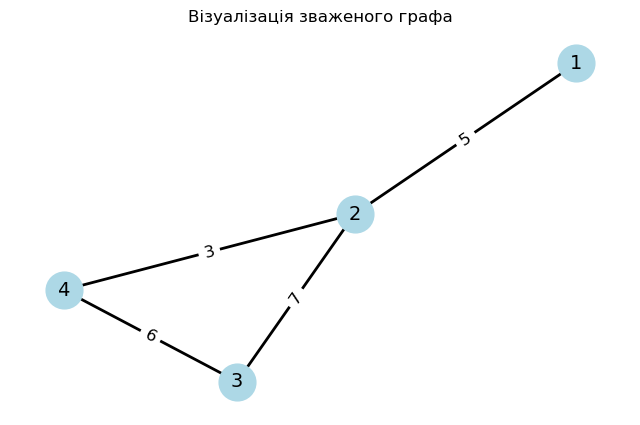

Оптимальний маршрут: None. Його вартість = 100000000000000000000


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

class Vertex:
    def __init__(self, key):
        self.id = key
        self.connectedTo = {}

    def addNeighbor(self, nbr, weight=0):
        self.connectedTo[nbr] = weight

    def __str__(self):
        return str(self.id) + ' connectedTo: ' + str([x.id for x in self.connectedTo])

    def getConnections(self):
        return self.connectedTo.keys()

    def getId(self):
        return self.id

    def getWeight(self, nbr):
        return self.connectedTo[nbr]


class Graph:
    def __init__(self):
        self.vertList = {}
        self.numVertices = 0

    def addVertex(self, key):
        self.numVertices += 1
        newVertex = Vertex(key)
        self.vertList[key] = newVertex
        return newVertex

    def getVertex(self, n):
        if n in self.vertList:
            return self.vertList[n]
        else:
            return None

    def __contains__(self, n):
        return n in self.vertList

    def addEdge(self, f, t, cost=0):
        if f not in self.vertList:
            self.addVertex(f)
        if t not in self.vertList:
            self.addVertex(t)
        self.vertList[f].addNeighbor(self.vertList[t], cost)

    def getVertices(self):
        return self.vertList.keys()

    def __iter__(self):
        return iter(self.vertList.values())


g = Graph()
graph_data = {
    'V0': {'V1': 5, 'V5': 2},
    'V1': {'V2': 4},
    'V2': {'V3': 9},
    'V3': {'V4': 7, 'V5': 3},
    'V4': {'V0': 1}, 
    'V5': {'V2': 1, 'V4': 8},
}

for item in graph_data:
    for item2 in graph_data[item]:
        g.addEdge(item, item2, graph_data[item][item2])

# --- Приклад 2. Вивід вершин, зв'язків та ваг ребер ---
print("--- Приклад 2. Вершини у графі та їх зв'язки ---")
for v in g:
    print(f"Вершина {v.getId()} з'єднана з: {[x.getId() for x in v.getConnections()]}")
    for nbr in v.getConnections():
        print(f"  -> Вага ребра ({v.getId()}, {nbr.getId()}): {v.getWeight(nbr)}")

G = nx.DiGraph()

for v in g:
    for nbr in v.getConnections():
        G.add_edge(v.getId(), nbr.getId(), weight=v.getWeight(nbr))

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, node_size=800, node_color="skyblue")
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold", font_family="sans-serif")
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), arrowstyle="->", arrowsize=20, edge_color="gray")

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color="red")

plt.title("Візуалізація зваженого направленого графа за варіантом")
plt.axis("off")
plt.show()

print("\n--- Алгоритм Дейкстри ---")
lengths, paths = nx.single_source_dijkstra(G, source='V0', weight='weight')

for target in lengths:
    print(f"Шлях до {target}: {paths[target]}, Довжина шляху: {lengths[target]}")


print("\n--- Алгоритм Беллмана–Форда ---")
bf_lengths = nx.single_source_bellman_ford_path_length(G, source='V0', weight='weight')
bf_paths = nx.single_source_bellman_ford_path(G, source='V0', weight='weight')

for target in bf_lengths:
    print(f"Шлях до {target}: {bf_paths[target]}, Довжина шляху: {bf_lengths[target]}")


print("\n--- Пошук у глибину (DFS) ---")

def dfs_paths(graph, start, goal, path=None):
    if path is None:
        path = [start]
    if start == goal:
        yield path
    for next_node in set(graph.adj[start].keys()) - set(path):
        yield from dfs_paths(graph, next_node, goal, path + [next_node])

all_dfs_paths = list(dfs_paths(G, 'V0', 'V3'))
print(f"Всі знайдені DFS шляхи від V0 до V3:")
for p in all_dfs_paths:
    print(p)

**Аналітична перевірка маршрутів:**  
До 2: через вершину 4 ($1 \rightarrow 4 \rightarrow 2$) разом: $1 + 2 = 3$ (коротше, ніж пряме ребро $7$).  
До 3: пряме ребро = $3$.До 4: пряме ребро = $1$.  
До 5: через вершину 4 ($1 \rightarrow 4 \rightarrow 5$) разом: $1 + 5 = 6$.  
До 6: через вершину 4 ($1 \rightarrow 4 \rightarrow 6$) разом: $1 + 4 = 5$.

###**Висновок:** під час виконання цієї практичної роботи я набув практичних навичок застосування деяких жадібних алгоритмів для розв’язання екстремальних задач.  
###Контрольні питання:
1. Жадібний алгоритм — це евристичний метод оптимізації та проектування алгоритмів, який полягає в ухваленні локально найкращого (найвигіднішого) рішення на кожному окремому кроці чи етапі обчислень у сподіванні, що така послідовність виборів зрештою приведе до загального глобально оптимального розв'язку всієї екстремальної задачі.
2. Головними принципами роботи є покрокове конструювання розв'язку, принцип жадібного вибору (вибирається елемент, який є найбільш вигідним саме в поточний момент часу без заглядання вперед) та принцип незалежності (ухвалене рішення є остаточним і ніколи не скасовується та не переглядається на наступних ітераціях).
3. Головна відмінність полягає в тому, що жадібний алгоритм приймає лише один локально оптимальний вибір на кожному кроці й рухається «наосліп» зверху вниз без аналізу майбутніх наслідків, тоді як динамічне програмування працює знизу вгору, перебирає та порівнює між собою розв'язки всіх можливих підзадач і гарантує знаходження точного глобального оптимуму завдяки збереженню проміжних станів.
4. За допомогою жадібної стратегії ефективно розв'язуються такі класичні проблеми, як задача знаходження найкоротших шляхів від одного джерела (алгоритм Дейкстри), пошук мінімального кістякового дерева графа (алгоритми Краскала та Пріма), побудова оптимальних кодів стиснення даних (алгоритм Гафмена), наближене розв'язання задачі комівояжера (метод найближчого сусіда), а також дробова задача про рюкзак.
5. Основним обмеженням є те, що для більшості складних комбінаторних та NP-складних задач жадібний вибір не гарантує знаходження точного глобально оптимального результату, а його ефективність критично залежить від математичної структури даних (наприклад, наявності властивості матроїда), через що алгоритм може легко потрапити в локальну пастку й повернути розв'язок, який суттєво гірший за істинний оптимум.
6. Вони використовуються завдяки своїй надзвичайній простоті в розумінні та програмній реалізації, а головне — через колосальну обчислювальну швидкість та низьку поліноміальну складність, що дозволяє за мінімальний час знаходити цілком прийнятні, близькі до оптимальних результати для задач величезної розмірності, де точні методи повного перебору чи динамічного програмування є неприйнятними.